In [1]:
pip install tensorflow

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,ReLU

In [3]:
classifier=Sequential()

In [4]:
classifier.add(Dense(units=11,activation='relu'))
classifier.add(Dropout(0.3))

In [5]:
classifier.add(Dense(units=20,activation='relu'))
classifier.add(Dropout(0.3))

In [6]:
classifier.add(Dense(units=15,activation='relu'))
classifier.add(Dropout(0.3))


In [7]:
classifier.add(Dense(units=1,activation='sigmoid'))

In [8]:
classifier.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

In [9]:
import numpy as np

X_train=np.load('X_train.npy')
Y_train=np.load('Y_train.npy')
X_test=np.load('X_test.npy')
Y_test=np.load('Y_test.npy')

In [10]:
model_history=classifier.fit(X_train,Y_train,validation_split=0.33,batch_size=10,epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7936 - loss: 0.5074 - val_accuracy: 0.8012 - val_loss: 0.4511
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7998 - loss: 0.4730 - val_accuracy: 0.8084 - val_loss: 0.4268
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8022 - loss: 0.4622 - val_accuracy: 0.8126 - val_loss: 0.4239
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8046 - loss: 0.4464 - val_accuracy: 0.8247 - val_loss: 0.4142
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8130 - loss: 0.4361 - val_accuracy: 0.8304 - val_loss: 0.4120
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8100 - loss: 0.4396 - val_accuracy: 0.8319 - val_loss: 0.4042
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8158 - loss: 0.4336 - val_accuracy: 0.8395 - val_loss: 0.4021
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8173 - loss: 0.4259 - val_acc

In [12]:
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [13]:
y_pred

array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]])

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,Y_test)

0.834

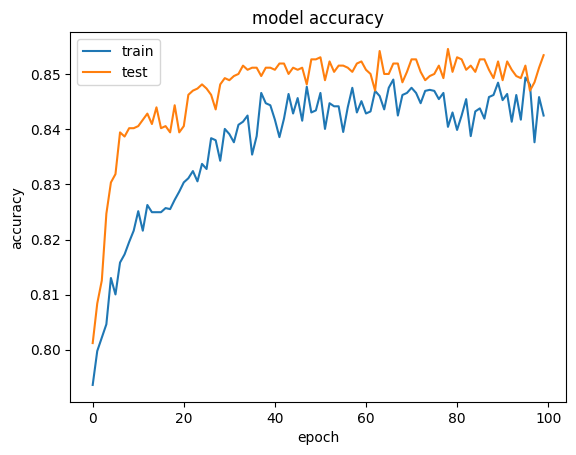

In [17]:
import matplotlib.pyplot as plt

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

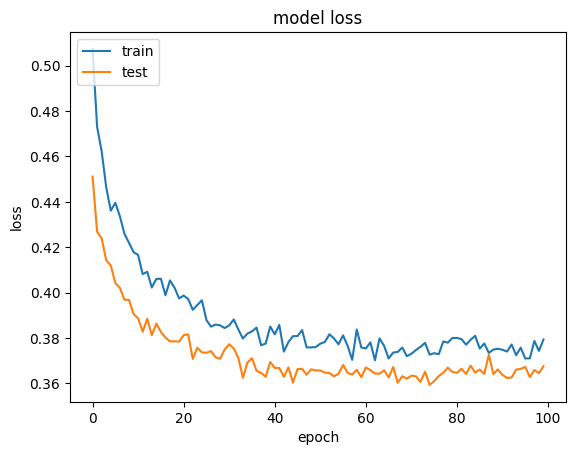

In [18]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [19]:
import joblib

joblib.dump(classifier, "classifier.pkl")

['classifier.pkl']